In [1]:
import pandas as pd
import datetime

apartments_df = pd.read_csv("data/processed_apartments_data_set.csv")
apartments_df["first_day_exposition"] = pd.to_datetime(apartments_df["first_day_exposition"])
display(apartments_df.head(10))
apartments_df.info()

,first_day_exposition,last_price,total_area,rooms,ceiling_height,floors_total,living_area,floor,studio,kitchen_area,balcony,locality_name,price_per_sqm
0,2021-01-18,1968750,48.20,2,2.50,5,27.400000,2,False,7.70,3,Boryspil,40845.435685
1,2021-01-26,19619188,95.80,2,2.65,6,58.300000,5,False,20.00,1,Kyiv,204793.194154
2,2021-02-14,5962500,80.00,3,2.85,17,44.000000,9,False,15.00,0,Kyiv,74531.250000
3,2021-03-26,7481250,79.60,2,3.00,8,42.700000,7,False,18.00,0,Kyiv,93985.552764
4,2021-03-27,2475000,42.98,1,2.65,5,18.720000,1,False,11.31,0,Irpin,57584.923220
5,2021-03-27,7481250,133.00,4,3.00,5,58.000000,2,False,45.00,0,Kyiv,56250.000000
6,2021-04-11,5343750,100.00,4,3.00,5,76.000000,5,False,10.00,0,Kyiv,53437.500000
7,2021-04-19,5218875,139.80,4,2.80,5,79.431818,4,False,9.10,0,Boryspil,37331.008584
8,2021-04-23,3369375,82.00,3,3.00,4,60.000000,2,False,8.00,0,Irpin,41089.939024
9,2021-04-24,6412500,76.00,2,2.65,9,36.000000,3,False,14.00,0,Kyiv,84375.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   first_day_exposition  23479 non-null  datetime64[ns]
 1   last_price            23479 non-null  int64         
 2   total_area            23479 non-null  float64       
 3   rooms                 23479 non-null  int64         
 4   ceiling_height        23479 non-null  float64       
 5   floors_total          23479 non-null  int64         
 6   living_area           23479 non-null  float64       
 7   floor                 23479 non-null  int64         
 8   studio                23479 non-null  bool          
 9   kitchen_area          23479 non-null  float64       
 10  balcony               23479 non-null  int64         
 11  locality_name         23479 non-null  object        
 12  price_per_sqm         23479 non-null  float64       
dtypes: bool(1), date

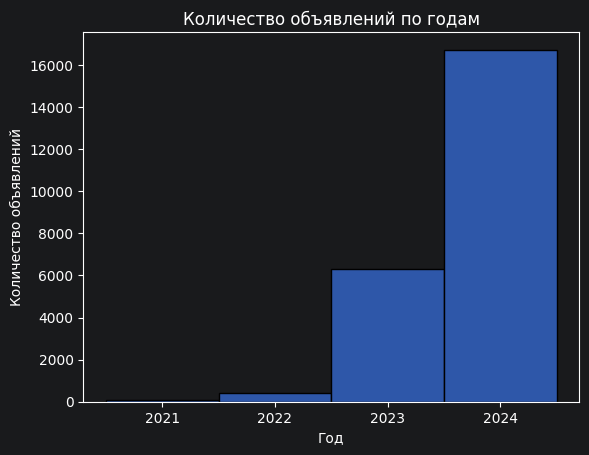

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

apartments_df["year"] = apartments_df["first_day_exposition"].dt.year
sns.histplot(apartments_df, x="year", discrete=True)
plt.title("Количество объявлений по годам")
plt.xlabel("Год")
plt.ylabel("Количество объявлений")
plt.xticks(sorted(apartments_df["year"].unique()))
plt.show()

<Axes: >

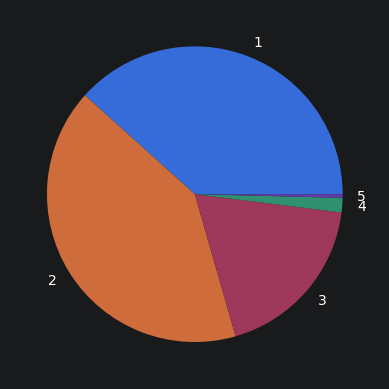

In [19]:
irpin_2023_df = apartments_df[
    (apartments_df["year"] == 2023) &
    (apartments_df["locality_name"] == "Irpin")
]
vehicle_style_df = irpin_2023_df.groupby(by="rooms").size()
vehicle_style_df.plot.pie(y = "rooms")

Text(15.750000000000009, 0.5, 'Количество объявлений')

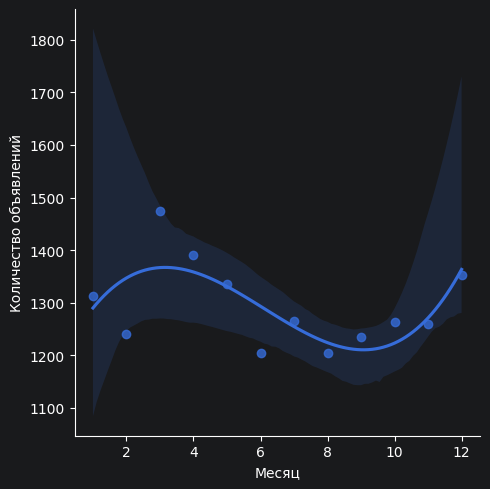

In [25]:
apartments_df["month"] = apartments_df["first_day_exposition"].dt.month
kyiv_df  = apartments_df[
    (apartments_df["locality_name"] == "Kyiv")
]
kyiv_monthly = kyiv_df.groupby(by="month").size().reset_index(name="count")
sns.lmplot(kyiv_monthly, x="month", y="count", order=3, scatter=True)
plt.xlabel("Месяц")
plt.ylabel("Количество объявлений")
